---
## 1 · Imports

In [ ]:
!pip install optuna

In [54]:
# Core
import re
import pickle
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import cycle

# NLTK
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Imbalanced
from imblearn.over_sampling import RandomOverSampler

# Sklearn — preprocessing
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, learning_curve
from sklearn.feature_extraction.text import TfidfVectorizer

# Sklearn — models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import BernoulliNB
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

# Sklearn — metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, log_loss, classification_report,
    roc_curve, auc
)

# Optuna
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

print('All imports OK ✓')

All imports OK ✓


---
## 2 · Load Data & EDA

In [3]:
df = pd.read_csv('Combined_Data.csv')
df.drop('Unnamed: 0', axis=1, inplace=True)
df.head()

,statement,status
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,I've shifted my focus to something else but I'...,Anxiety
4,"I'm restless and restless, it's been a month n...",Anxiety


In [4]:
print('Shape          :', df.shape)
print('Null values    :\n', df.isnull().sum())
print('Duplicate rows :', df.duplicated().sum())
print('\nClass distribution:')
print(df['status'].value_counts())

Shape          : (53043, 2)
Null values    :
 statement    362
status         0
dtype: int64
Duplicate rows : 1944

Class distribution:
status
Normal                  16351
Depression              15404
Suicidal                10653
Anxiety                  3888
Bipolar                  2877
Stress                   2669
Personality disorder     1201
Name: count, dtype: int64


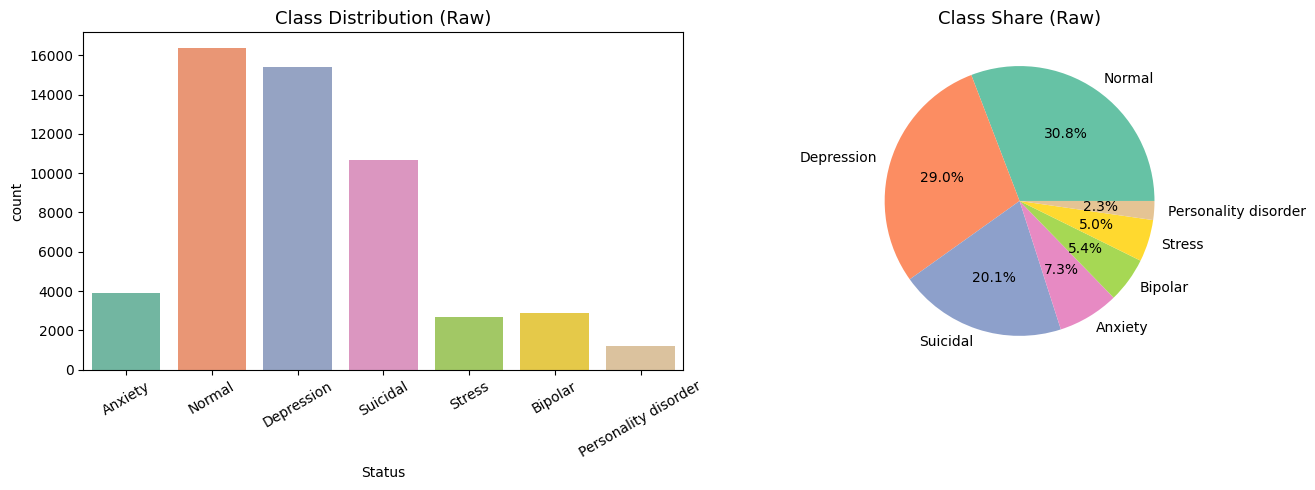

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
sns.countplot(x='status', data=df, palette='Set2', ax=axes[0])
axes[0].set_title('Class Distribution (Raw)', fontsize=13)
axes[0].set_xlabel('Status')
axes[0].tick_params(axis='x', rotation=30)

# Pie chart
df['status'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[1],
                                  colors=sns.color_palette('Set2'))
axes[1].set_title('Class Share (Raw)', fontsize=13)
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

---
## 3 · Data Cleaning  

In [6]:
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)
print(f'After cleaning: {df.shape}  |  classes: {df.status.value_counts().to_dict()}')

After cleaning: (51093, 2)  |  classes: {'Normal': 16040, 'Depression': 15094, 'Suicidal': 10644, 'Anxiety': 3623, 'Bipolar': 2501, 'Stress': 2296, 'Personality disorder': 895}


In [7]:
# ── Subsample + oversample to balance classes ─────────────────────────────────
df = df.sample(n=6000, random_state=42).reset_index(drop=True)

X = df.drop(['status'], axis=1)
y = df.status

sampler = RandomOverSampler(sampling_strategy='auto', random_state=42)
X_resampled, y_resampled = sampler.fit_resample(X, y)

df = pd.concat([X_resampled, y_resampled], axis=1)
print('Class distribution after oversampling:')
print(df['status'].value_counts())

Class distribution after oversampling:
status
Suicidal                1905
Stress                  1905
Depression              1905
Normal                  1905
Anxiety                 1905
Personality disorder    1905
Bipolar                 1905
Name: count, dtype: int64


In [8]:
# ── Feature engineering ───────────────────────────────────────────────────────
no_of_words = df.statement.apply(lambda x: len(x.split()))
no_of_lines = df.statement.apply(lambda x: len(x.split('.')))

df = pd.concat([df, no_of_words, no_of_lines], axis=1)
df.columns = ['statement', 'status', 'no_of_words', 'no_of_lines']
df.head()

,statement,status,no_of_words,no_of_lines
0,I take 100 mg orally How much zoloft is too much?,Suicidal,11,1
1,Sometimes my voice catches for a minute and I ...,Stress,30,6
2,"i am 17f and first of all, my family got issue...",Depression,225,14
3,I already have a plan. Ill wait until late at ...,Suicidal,66,7
4,WHAT DO YOU SAY TO DREAMIES??!!!,Normal,6,1


In [ ]:
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet',   quiet=True)

stop_words = nltk.corpus.stopwords.words('english')

def cleaning(text):
    preprocessed = text.lower()
    preprocessed = re.sub(r'[^a-zA-Z\s]', '', preprocessed)
    words = nltk.word_tokenize(preprocessed)
    filtered_words = [word for word in words if word not in stop_words]
    lemma = WordNetLemmatizer()
    filtered_words = [lemma.lemmatize(word) for word in filtered_words]
    return ' '.join(filtered_words)

df.statement = df.statement.apply(cleaning)
print('Text cleaning done ✓')
df.head(2)

Text cleaning done ✓


,statement,status,no_of_words,no_of_lines
0,take mg orally much zoloft much,Suicidal,11,1
1,sometimes voice catch minute flush dark red fe...,Stress,30,6


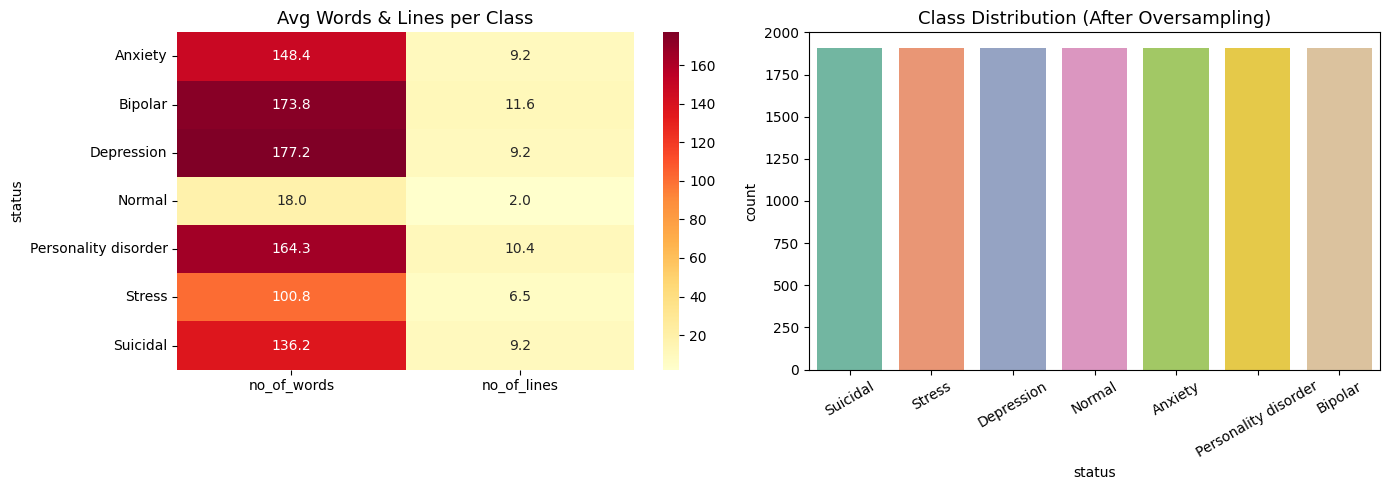

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

grouped = df.groupby('status')[['no_of_words', 'no_of_lines']].mean()
sns.heatmap(grouped, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[0])
axes[0].set_title('Avg Words & Lines per Class', fontsize=13)

sns.countplot(x='status', data=df, palette='Set2', ax=axes[1])
axes[1].set_title('Class Distribution (After Oversampling)', fontsize=13)
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [11]:
df.to_csv('Preprocessed.csv', index=False)
print('Saved → Preprocessed.csv')

Saved → Preprocessed.csv


---
## 4 · Vectorisation & Train/Test Split

In [12]:
X = df.statement
y = df.status

le = LabelEncoder()
y = le.fit_transform(y)
print('Classes:', list(le.classes_))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {len(X_train)}  |  Test: {len(X_test)}')

Classes: ['Anxiety', 'Bipolar', 'Depression', 'Normal', 'Personality disorder', 'Stress', 'Suicidal']
Train: 10668  |  Test: 2667


In [13]:
# TF-IDF  (same params as your original notebook)
tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1, 3))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print('X_train_tfidf:', X_train_tfidf.shape)
print('X_test_tfidf :', X_test_tfidf.shape)

X_train_tfidf: (10668, 3000)
X_test_tfidf : (2667, 3000)


---
## 5 · Model Comparison 

In [55]:
MODELS = [
    ('Logistic Regression',   LogisticRegression(max_iter=1000, n_jobs=-1)),
    ('Linear SVC',            LinearSVC(max_iter=2000)),
    ('Decision Tree',         DecisionTreeClassifier(max_depth=135)),
    ('Random Forest',         RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)),
    ('Extra Trees',           ExtraTreesClassifier(n_estimators=100,  n_jobs=-1, random_state=42)),
    ('Gradient Boosting',     GradientBoostingClassifier(n_estimators=100, random_state=42)),
    ('BernoulliNB',           BernoulliNB()),
    ('KNN',                   KNeighborsClassifier(n_neighbors=7, n_jobs=-1)),
    ("XGBoost",               XGBClassifier(use_label_encoder=False, eval_metric='logloss', verbosity=0))
]

In [15]:
def evaluate(name, model, X_tr, y_tr, X_te, y_te, verbose=True):
    """Fit model, return metrics dict. Prints train+test summary."""
    model.fit(X_tr, y_tr)

    y_pred_te = model.predict(X_te)
    y_pred_tr = model.predict(X_tr)

    metrics = dict(
        Model     = name,
        Test_Acc  = round(accuracy_score(y_te, y_pred_te)  * 100, 2),
        Test_F1   = round(f1_score(y_te, y_pred_te, average='weighted', zero_division=0) * 100, 2),
        Train_Acc = round(accuracy_score(y_tr, y_pred_tr) * 100, 2),
    )

    if verbose:
        print(f"  {name:<25}  Test Acc: {metrics['Test_Acc']:6.2f}%   "
              f"F1: {metrics['Test_F1']:6.2f}%   "
              f"Train Acc: {metrics['Train_Acc']:6.2f}%")
    return metrics

In [56]:
results = []
for name, model in MODELS:
    try:
        r = evaluate(name, model, X_train_tfidf, y_train, X_test_tfidf, y_test)
        results.append(r)
    except Exception as e:
        print(f'  {name:<25}  FAILED — {e}')

results_df = pd.DataFrame(results).sort_values('Test_Acc', ascending=False).reset_index(drop=True)
print('\n' + '='*60)
print(results_df.to_string(index=False))

  Logistic Regression        Test Acc:  87.63%   F1:  87.33%   Train Acc:  93.92%
  Linear SVC                 Test Acc:  89.99%   F1:  89.73%   Train Acc:  97.77%
  Decision Tree              Test Acc:  87.59%   F1:  87.07%   Train Acc:  99.96%
  Random Forest              Test Acc:  91.64%   F1:  91.45%   Train Acc:  99.96%
  Extra Trees                Test Acc:  92.50%   F1:  92.40%   Train Acc:  99.96%
  Gradient Boosting          Test Acc:  84.40%   F1:  84.01%   Train Acc:  90.43%
  BernoulliNB                Test Acc:  67.64%   F1:  68.36%   Train Acc:  70.88%
  KNN                        Test Acc:  59.99%   F1:  56.78%   Train Acc:  65.42%
  XGBoost                    Test Acc:  90.89%   F1:  90.68%   Train Acc:  98.34%

              Model  Test_Acc  Test_F1  Train_Acc
        Extra Trees     92.50    92.40      99.96
      Random Forest     91.64    91.45      99.96
            XGBoost     90.89    90.68      98.34
         Linear SVC     89.99    89.73      97.77
Logistic Re

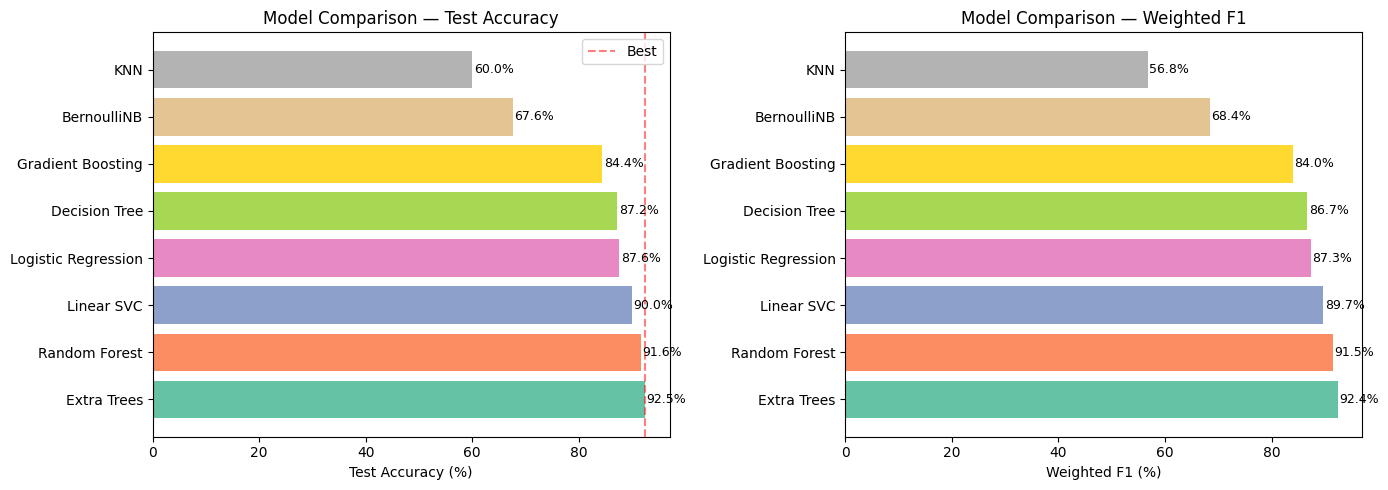

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

palette = sns.color_palette('Set2', len(results_df))

# Test Accuracy
axes[0].barh(results_df['Model'], results_df['Test_Acc'], color=palette)
axes[0].set_xlabel('Test Accuracy (%)')
axes[0].set_title('Model Comparison — Test Accuracy')
axes[0].axvline(results_df['Test_Acc'].max(), color='red', linestyle='--', alpha=0.5, label='Best')
axes[0].legend()
for i, v in enumerate(results_df['Test_Acc']):
    axes[0].text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=9)

# Test F1
axes[1].barh(results_df['Model'], results_df['Test_F1'], color=palette)
axes[1].set_xlabel('Weighted F1 (%)')
axes[1].set_title('Model Comparison — Weighted F1')
for i, v in enumerate(results_df['Test_F1']):
    axes[1].text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

---
## 6 · Hyperparameter Tuning — Optuna on RandomForest

In [18]:
# Check train vs test across depths
for depth in [20, 30, 50, 80, 100, 120, None]:
    m = ExtraTreesClassifier(n_estimators=100, max_depth=depth, random_state=42, n_jobs=-1)
    m.fit(X_train_tfidf, y_train)
    tr = accuracy_score(y_train, m.predict(X_train_tfidf))
    te = accuracy_score(y_test,  m.predict(X_test_tfidf))
    print(f'max_depth={str(depth):<5}  train={tr*100:.2f}%  test={te*100:.2f}%  gap={( tr-te)*100:.2f}%')

max_depth=20     train=89.15%  test=82.34%  gap=6.81%
max_depth=30     train=92.59%  test=85.00%  gap=7.58%
max_depth=50     train=95.40%  test=87.70%  gap=7.70%
max_depth=80     train=97.66%  test=90.55%  gap=7.11%
max_depth=100    train=98.38%  test=90.78%  gap=7.60%
max_depth=120    train=98.99%  test=91.04%  gap=7.95%
max_depth=None   train=99.96%  test=92.50%  gap=7.46%


In [19]:
# Check train vs test across depths
for depth in [20, 30, 50, 80, 100, 120, None]:
    m = RandomForestClassifier(n_estimators=100, max_depth=depth, random_state=42, n_jobs=-1)
    m.fit(X_train_tfidf, y_train)
    tr = accuracy_score(y_train, m.predict(X_train_tfidf))
    te = accuracy_score(y_test,  m.predict(X_test_tfidf))
    print(f'max_depth={str(depth):<5}  train={tr*100:.2f}%  test={te*100:.2f}%  gap={( tr-te)*100:.2f}%')

max_depth=20     train=91.37%  test=84.85%  gap=6.51%
max_depth=30     train=94.72%  test=87.44%  gap=7.28%
max_depth=50     train=97.98%  test=90.33%  gap=7.66%
max_depth=80     train=99.09%  test=90.81%  gap=8.28%
max_depth=100    train=99.48%  test=90.93%  gap=8.56%
max_depth=120    train=99.65%  test=90.96%  gap=8.69%
max_depth=None   train=99.96%  test=91.64%  gap=8.32%


In [26]:
N_TRIALS     = 100
N_CV_FOLDS   = 3
RANDOM_STATE = 42

cv = StratifiedKFold(n_splits=N_CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

def objective(trial):
    params = dict(
        n_estimators      = trial.suggest_int('n_estimators',      80, 400, step=40),
        min_samples_split = trial.suggest_int('min_samples_split',  2,  10),
        min_samples_leaf  = trial.suggest_int('min_samples_leaf',   1,   4),
        max_features      = trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        criterion         = trial.suggest_categorical('criterion',    ['gini', 'entropy']),
        random_state      = RANDOM_STATE,
        n_jobs            = 1,
    )
    model = ExtraTreesClassifier(**params)

    idx   = np.random.default_rng(trial.number).choice(len(y_train), size=int(0.6 * len(y_train)), replace=False)
    X_sub = X_train_tfidf[idx]
    y_sub = y_train[idx]

    scores = cross_val_score(model, X_sub, y_sub, cv=cv, scoring='f1_weighted', n_jobs=-1)
    return scores.mean()

print(f'Starting Optuna study — {N_TRIALS} trials, {N_CV_FOLDS}-fold CV…')

Starting Optuna study — 100 trials, 3-fold CV…


In [27]:
study = optuna.create_study(
    direction  = 'maximize',
    sampler    = optuna.samplers.TPESampler(seed=RANDOM_STATE),
    pruner     = optuna.pruners.MedianPruner(n_startup_trials=5),
    study_name = 'Et_sentiment',
)

# Seed with your known best params — Trial 0 starts at ~92% immediately
study.enqueue_trial({
    'n_estimators':       100,
    'min_samples_split':    2,
    'min_samples_leaf':     1,
    'max_features':      'sqrt',
    'criterion':         'gini',
})

study.optimize(objective, n_trials=N_TRIALS, n_jobs=-1, show_progress_bar=True)

print(f'\nBest CV F1  : {study.best_value:.4f}  ({study.best_value*100:.2f}%)')
print(f'Best params : {study.best_params}')

  0%|          | 0/100 [00:00<?, ?it/s]


Best CV F1  : 0.8799  (87.99%)
Best params : {'n_estimators': 400, 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'criterion': 'gini'}


In [28]:
best_model_et = ExtraTreesClassifier(
    **study.best_params,
    random_state = RANDOM_STATE,
    n_jobs       = -1,
)
best_model_et.fit(X_train_tfidf, y_train)

y_pred = best_model_et.predict(X_test_tfidf)

print(f'Accuracy : {accuracy_score(y_test, y_pred)*100:.2f}%')
print(f'F1       : {f1_score(y_test, y_pred, average="weighted")*100:.2f}%')
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy : 92.46%
F1       : 92.43%
                      precision    recall  f1-score   support

             Anxiety       0.99      1.00      0.99       381
             Bipolar       0.99      1.00      1.00       381
          Depression       0.78      0.77      0.78       381
              Normal       0.91      0.91      0.91       381
Personality disorder       1.00      1.00      1.00       381
              Stress       0.99      1.00      1.00       381
            Suicidal       0.80      0.79      0.80       381

            accuracy                           0.92      2667
           macro avg       0.92      0.92      0.92      2667
        weighted avg       0.92      0.92      0.92      2667



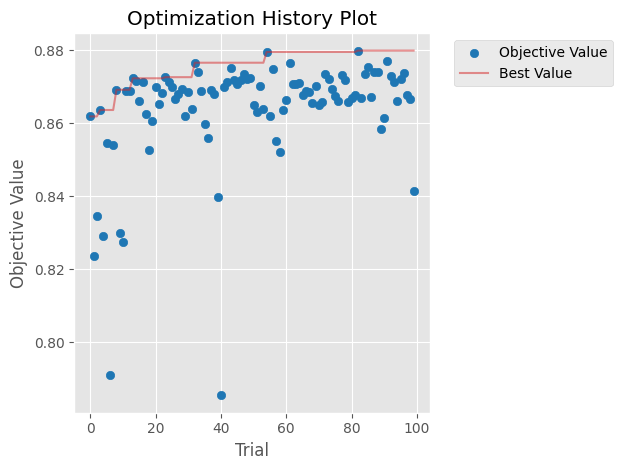

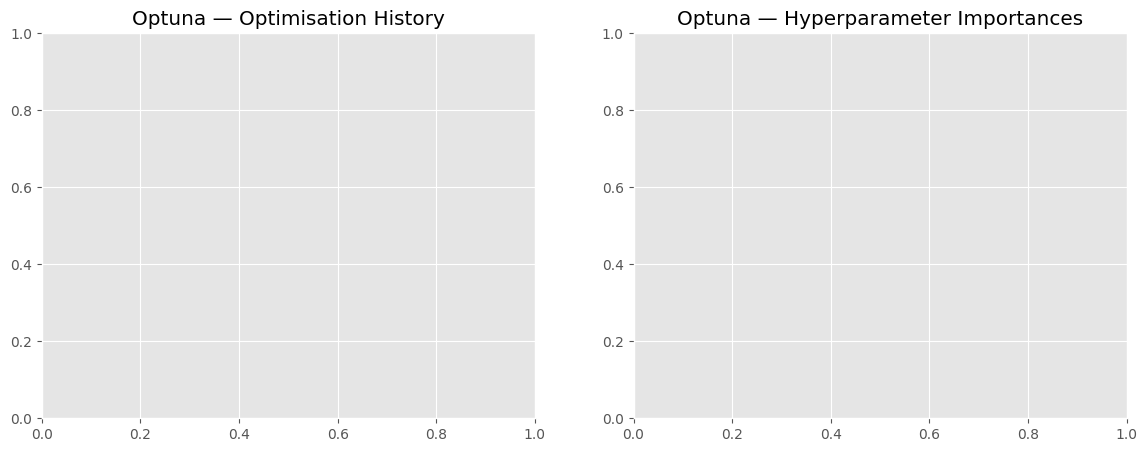

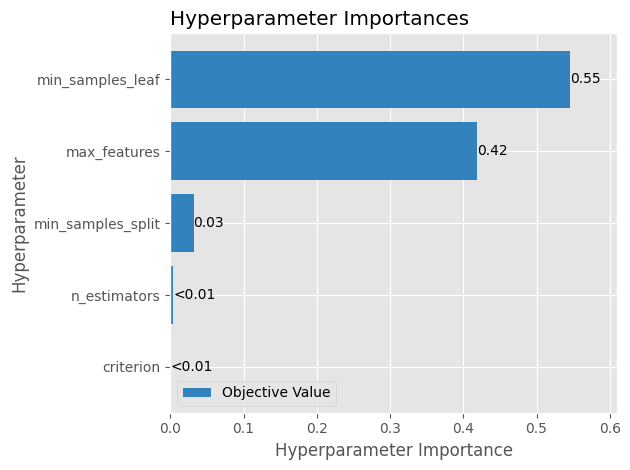

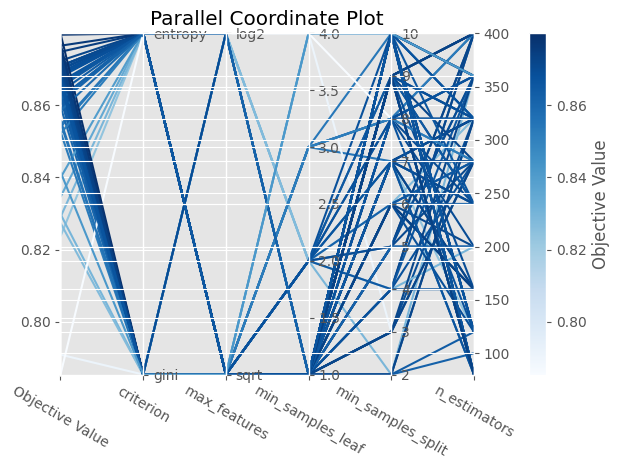

In [29]:
# ── Optuna visualisations ─────────────────────────────────────────────────────
from optuna.visualization.matplotlib import (
    plot_optimization_history,
    plot_param_importances,
    plot_parallel_coordinate,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plt.sca(axes[0]); plot_optimization_history(study)
axes[0].set_title('Optuna — Optimisation History')
plt.sca(axes[1]); plot_param_importances(study)
axes[1].set_title('Optuna — Hyperparameter Importances')
plt.tight_layout()
plt.show()

plot_parallel_coordinate(study)
plt.tight_layout()
plt.show()

In [30]:
# ── Config ────────────────────────────────────────────────────────────────────
N_TRIALS_RF  = 100
N_CV_FOLDS   = 3
RANDOM_STATE = 42

cv_rf = StratifiedKFold(n_splits=N_CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

def objective_rf(trial):
    params = dict(
        n_estimators      = trial.suggest_int('n_estimators',      80, 400, step=40),
        min_samples_split = trial.suggest_int('min_samples_split',  2,  10),
        min_samples_leaf  = trial.suggest_int('min_samples_leaf',   1,   4),
        max_features      = trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        criterion         = trial.suggest_categorical('criterion',    ['gini', 'entropy']),
        bootstrap         = trial.suggest_categorical('bootstrap',    [True, False]),
        random_state      = RANDOM_STATE,
        n_jobs            = 1,
    )
    model = RandomForestClassifier(**params)

    idx   = np.random.default_rng(trial.number).choice(len(y_train), size=int(0.6 * len(y_train)), replace=False)
    X_sub = X_train_tfidf[idx]
    y_sub = y_train[idx]

    scores = cross_val_score(model, X_sub, y_sub, cv=cv_rf, scoring='f1_weighted', n_jobs=-1)
    return scores.mean()

print(f'Starting Optuna study — {N_TRIALS_RF} trials, {N_CV_FOLDS}-fold CV…')

Starting Optuna study — 100 trials, 3-fold CV…


In [31]:
study_rf = optuna.create_study(
    direction  = 'maximize',
    sampler    = optuna.samplers.TPESampler(seed=RANDOM_STATE),
    pruner     = optuna.pruners.MedianPruner(n_startup_trials=5),
    study_name = 'RF_sentiment',
)

study_rf.enqueue_trial({
    'n_estimators':      100,
    'min_samples_split':   2,
    'min_samples_leaf':    1,
    'max_features':     'sqrt',
    'criterion':        'gini',
    'bootstrap':         True,
})

study_rf.optimize(objective_rf, n_trials=N_TRIALS_RF, n_jobs=-1, show_progress_bar=True)

print(f'\nBest CV F1  : {study_rf.best_value:.4f}  ({study_rf.best_value*100:.2f}%)')
print(f'Best params : {study_rf.best_params}')

  0%|          | 0/100 [00:00<?, ?it/s]


Best CV F1  : 0.8754  (87.54%)
Best params : {'n_estimators': 200, 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'log2', 'criterion': 'gini', 'bootstrap': False}


In [34]:
best_model_rf = RandomForestClassifier(
    **study_rf.best_params,
    random_state = RANDOM_STATE,
    n_jobs       = -1,
)
best_model_rf.fit(X_train_tfidf, y_train)

y_pred = best_model_rf.predict(X_test_tfidf)

print(f'Accuracy : {accuracy_score(y_test, y_pred)*100:.2f}%')
print(f'F1       : {f1_score(y_test, y_pred, average="weighted")*100:.2f}%')
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy : 91.90%
F1       : 91.78%
                      precision    recall  f1-score   support

             Anxiety       0.98      1.00      0.99       381
             Bipolar       1.00      1.00      1.00       381
          Depression       0.77      0.75      0.76       381
              Normal       0.86      0.95      0.90       381
Personality disorder       1.00      1.00      1.00       381
              Stress       1.00      1.00      1.00       381
            Suicidal       0.81      0.74      0.77       381

            accuracy                           0.92      2667
           macro avg       0.92      0.92      0.92      2667
        weighted avg       0.92      0.92      0.92      2667



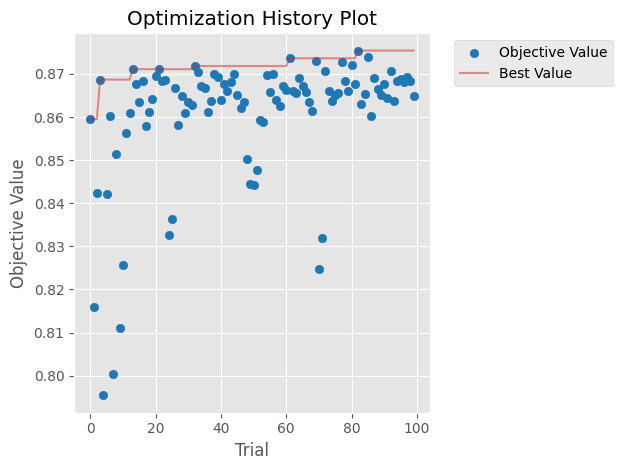

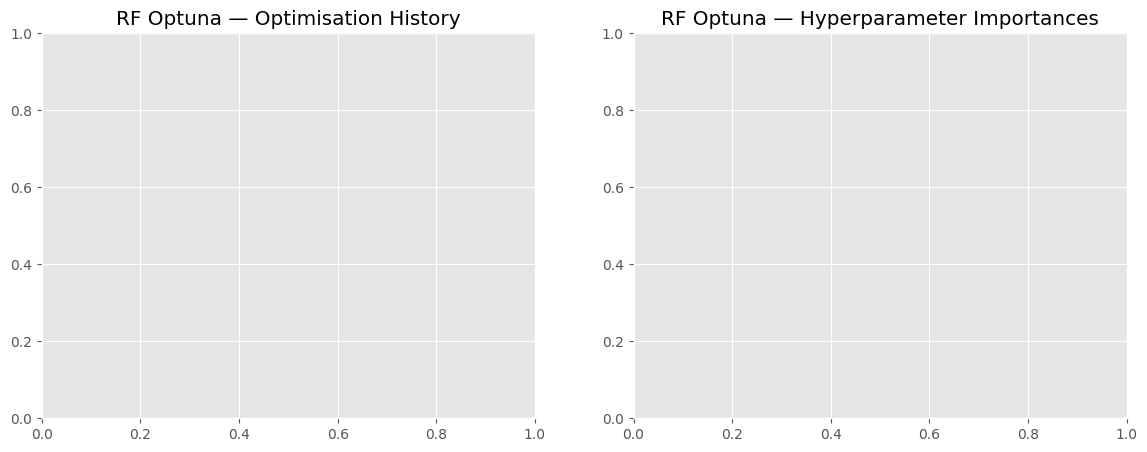

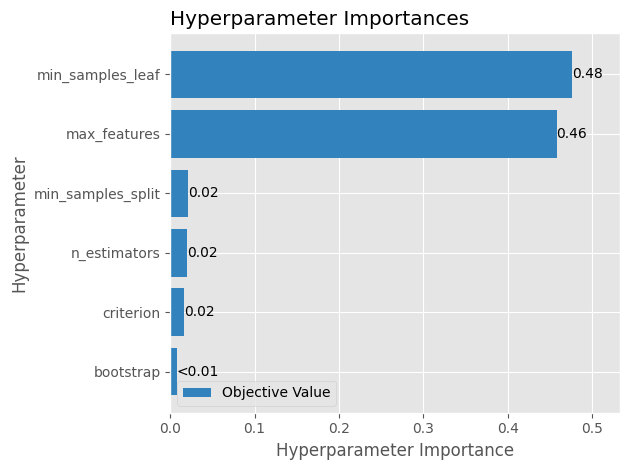

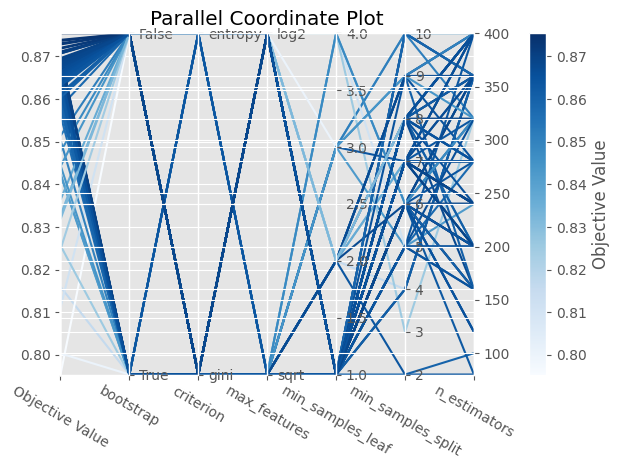

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plt.sca(axes[0]); plot_optimization_history(study_rf)
axes[0].set_title('RF Optuna — Optimisation History')
plt.sca(axes[1]); plot_param_importances(study_rf)
axes[1].set_title('RF Optuna — Hyperparameter Importances')
plt.tight_layout()
plt.show()

plot_parallel_coordinate(study_rf)
plt.tight_layout()
plt.show()

---
## 7 · Train Final Model on Full Training Set

In [40]:
best_params = {**study_rf.best_params, 'random_state': RANDOM_STATE, 'n_jobs': -1}
print('Final model params:', best_params)

best_model = RandomForestClassifier(**best_params)
best_model.fit(X_train_tfidf, y_train)
print('Training complete ✓')

Final model params: {'n_estimators': 200, 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'log2', 'criterion': 'gini', 'bootstrap': False, 'random_state': 42, 'n_jobs': -1}
Training complete ✓


---
## 8 · Evaluation

In [41]:
y_pred       = best_model.predict(X_test_tfidf)
y_pred_proba = best_model.predict_proba(X_test_tfidf)

test_acc = accuracy_score(y_test, y_pred)
test_f1  = f1_score(y_test, y_pred, average='weighted')
loss     = log_loss(y_test, y_pred_proba)

print('=' * 50)
print(f'  Test Accuracy  : {test_acc*100:.2f}%')
print(f'  Test F1        : {test_f1*100:.2f}%')
print(f'  Log Loss       : {loss:.4f}')
print('=' * 50)
print()
print(classification_report(y_test, y_pred, target_names=le.classes_, digits=4))

  Test Accuracy  : 91.90%
  Test F1        : 91.78%
  Log Loss       : 0.2654

                      precision    recall  f1-score   support

             Anxiety     0.9845    1.0000    0.9922       381
             Bipolar     1.0000    1.0000    1.0000       381
          Depression     0.7696    0.7454    0.7573       381
              Normal     0.8595    0.9475    0.9014       381
Personality disorder     1.0000    1.0000    1.0000       381
              Stress     1.0000    1.0000    1.0000       381
            Suicidal     0.8103    0.7402    0.7737       381

            accuracy                         0.9190      2667
           macro avg     0.9177    0.9190    0.9178      2667
        weighted avg     0.9177    0.9190    0.9178      2667



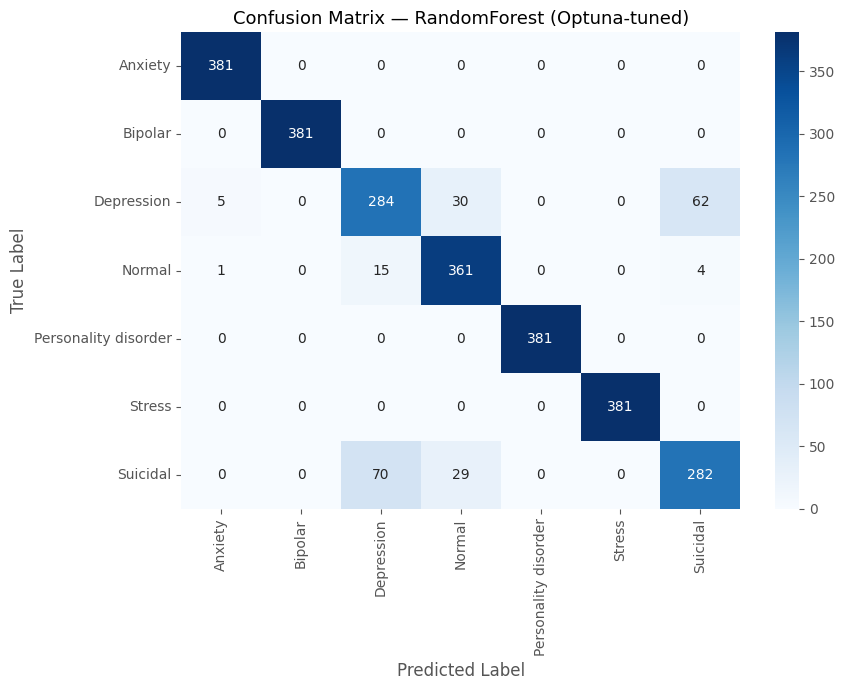

In [42]:
# ── Confusion Matrix ──────────────────────────────────────────────────────────
y_test_labels = le.inverse_transform(y_test)
y_pred_labels = le.inverse_transform(y_pred)
classes       = le.classes_

cm = confusion_matrix(y_test_labels, y_pred_labels, labels=classes)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix — RandomForest (Optuna-tuned)', fontsize=13)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

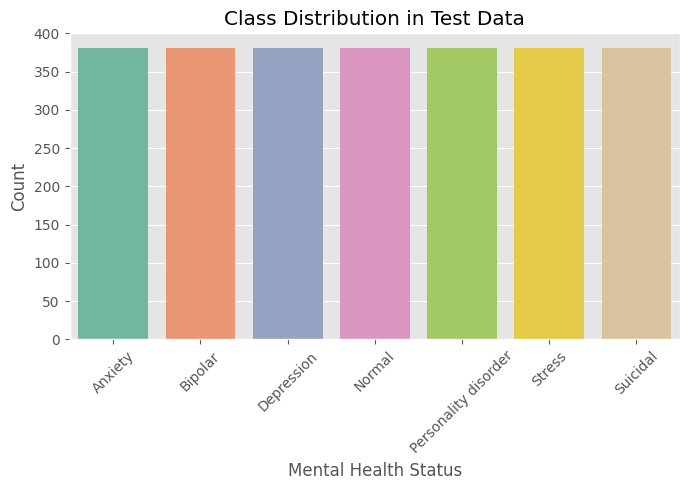

In [43]:
# ── Class Distribution in Test Set ───────────────────────────────────────────
plt.figure(figsize=(7, 5))
sns.countplot(x=y_test_labels, order=classes, palette='Set2')
plt.title('Class Distribution in Test Data')
plt.xlabel('Mental Health Status')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

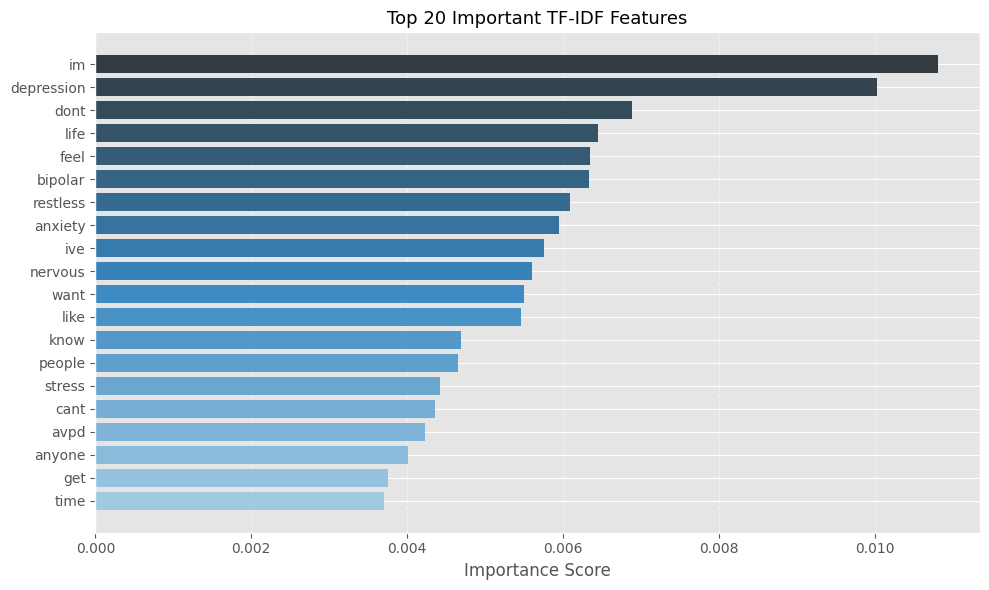

In [44]:
# ── Top 20 TF-IDF Feature Importances ────────────────────────────────────────
feature_names = tfidf.get_feature_names_out()
importances   = best_model.feature_importances_
top_idx       = np.argsort(importances)[-20:]

plt.figure(figsize=(10, 6))
plt.barh(feature_names[top_idx], importances[top_idx],
         color=sns.color_palette('Blues_d', 20))
plt.title('Top 20 Important TF-IDF Features', fontsize=13)
plt.xlabel('Importance Score')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

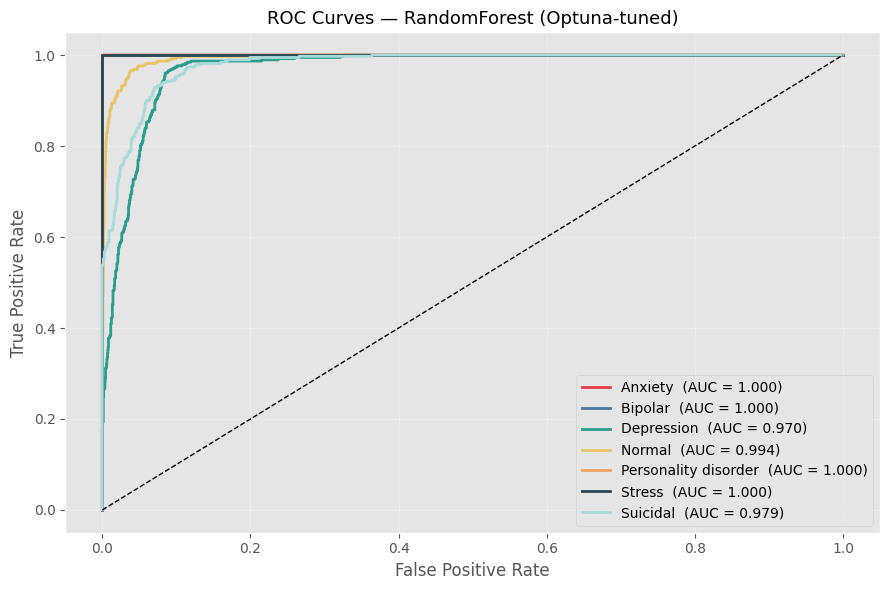

In [45]:
# ── ROC Curves (one-vs-rest) ──────────────────────────────────────────────────
y_test_bin = label_binarize(y_test, classes=range(len(classes)))
n_classes  = y_test_bin.shape[1]

fpr, tpr, roc_auc = {}, {}, {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc[i]        = auc(fpr[i], tpr[i])

plt.figure(figsize=(9, 6))
colors = cycle(['#E63946', '#457B9D', '#2A9D8F', '#E9C46A', '#F4A261', '#264653', '#A8DADC'])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'{classes[i]}  (AUC = {roc_auc[i]:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — RandomForest (Optuna-tuned)', fontsize=13)
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

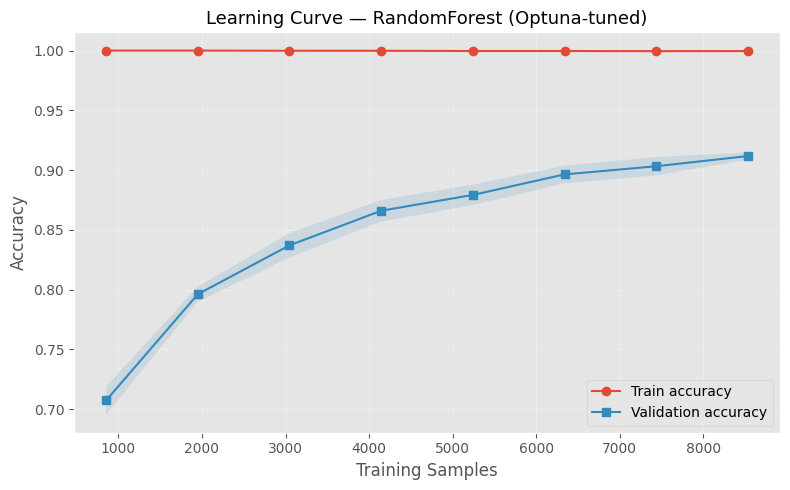

In [47]:
# ── Learning Curve ────────────────────────────────────────────────────────────
train_sizes, train_scores, val_scores = learning_curve(
    estimator    = RandomForestClassifier(**best_params),
    X            = X_train_tfidf,
    y            = y_train,
    train_sizes  = np.linspace(0.1, 1.0, 8),
    cv           = 5,
    scoring      = 'accuracy',
    n_jobs       = -1,
)

tr_mean, tr_std = train_scores.mean(1), train_scores.std(1)
va_mean, va_std = val_scores.mean(1),   val_scores.std(1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, tr_mean, 'o-', label='Train accuracy')
plt.plot(train_sizes, va_mean, 's-', label='Validation accuracy')
plt.fill_between(train_sizes, tr_mean - tr_std, tr_mean + tr_std, alpha=0.15)
plt.fill_between(train_sizes, va_mean - va_std, va_mean + va_std, alpha=0.15)
plt.title('Learning Curve — RandomForest (Optuna-tuned)', fontsize=13)
plt.xlabel('Training Samples')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 9 · Save Artifacts with Pickle

> After running this cell, download **`model.pkl`**, **`tfidf.pkl`**, and **`encoder.pkl`** from your working directory and place them in the `artifacts/` folder that the FastAPI backend reads from.

In [51]:
import os, pickle, zipfile
from google.colab import files

# ── Save artifacts ────────────────────────────────────────────────────────────
os.makedirs('artifacts', exist_ok=True)

for path, obj in {
    'artifacts/model.pkl'   : best_model,
    'artifacts/tfidf.pkl'   : tfidf,
    'artifacts/encoder.pkl' : le,
}.items():
    with open(path, 'wb') as f:
        pickle.dump(obj, f)
    print(f'  Saved → {path}')

# ── Zip ───────────────────────────────────────────────────────────────────────
zip_path = 'model.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    zf.write('artifacts/model.pkl',   'model.pkl')
    zf.write('artifacts/tfidf.pkl',   'tfidf.pkl')
    zf.write('artifacts/encoder.pkl', 'encoder.pkl')

size_mb = os.path.getsize(zip_path) / (1024 * 1024)
print(f'\nZipped → {zip_path}  ({size_mb:.1f} MB)')
for info in zipfile.ZipFile(zip_path).infolist():
    print(f'  {info.filename:<20} {info.file_size/1024:.1f} KB')

# ── Download ──────────────────────────────────────────────────────────────────
files.download(zip_path)
print('\nDownload started ✓')

Created model.zip  (27.3 MB)
Contents:
  model.pkl             149901.9 KB
  tfidf.pkl             110.4 KB
  encoder.pkl           0.3 KB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [52]:
# ── Quick sanity-check inference ──────────────────────────────────────────────
def quick_predict(text):
    cleaned = cleaning(text)
    vec     = tfidf.transform([cleaned])
    idx     = best_model.predict(vec)[0]
    proba   = best_model.predict_proba(vec)[0]
    label   = le.inverse_transform([idx])[0]
    conf    = proba[idx]
    return label, conf

test_sentences = [
    "I feel so hopeless and empty, nothing brings me joy anymore.",
    "I'm feeling anxious and can't stop worrying about everything.",
    "Today was a great day, I feel motivated and happy!",
    "I can't sleep, I keep hearing voices and seeing things that aren't there.",
    "I have so much energy, I barely need sleep, my thoughts are racing.",
]

print('Quick inference check\n' + '-'*55)
for sent in test_sentences:
    label, conf = quick_predict(sent)
    print(f'  {label:<15}  ({conf*100:.1f}%)  →  {sent[:55]}…')

Quick inference check
-------------------------------------------------------
  Depression       (34.3%)  →  I feel so hopeless and empty, nothing brings me joy any…
  Normal           (36.7%)  →  I'm feeling anxious and can't stop worrying about every…
  Normal           (52.1%)  →  Today was a great day, I feel motivated and happy!…
  Normal           (57.4%)  →  I can't sleep, I keep hearing voices and seeing things …
  Normal           (54.9%)  →  I have so much energy, I barely need sleep, my thoughts…
